In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('mockup_credit_card_excel_1000_rows.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   segment            1000 non-null   object 
 3   region             1000 non-null   object 
 4   tenure_months      1000 non-null   int64  
 5   credit_limit       1000 non-null   int64  
 6   avg_monthly_spend  1000 non-null   float64
 7   txns_last_3mo      1000 non-null   int64  
 8   days_past_due      1000 non-null   int64  
 9   churn_flag         1000 non-null   int64  
 10  current_balance    1000 non-null   float64
 11  utilization_rate   1000 non-null   float64
 12  pct_revolve        1000 non-null   float64
 13  revolve_balance    1000 non-null   float64
 14  delinquent_flag    1000 non-null   int64  
dtypes: float64(5), int64(8), object(2)
memory usage: 117.3+ KB


In [34]:
#data sanity check:
df.describe()
#upon checking, there is some discrepancy such as: utilization_rate is beyond abnormal amount.
#action: check for such data

,customer_id,age,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,100500.500000,45.379000,91.795000,67520.000000,17948.161000,21.990000,4.350000,0.12100,27709.239000,0.630640,0.393220,10979.222000,0.089000
std,288.819436,14.122138,52.230403,43395.077287,8564.553391,4.701277,15.362731,0.32629,17931.719874,0.676334,0.193573,9602.999673,0.284886
min,100001.000000,21.000000,1.000000,20000.000000,1000.000000,10.000000,0.000000,0.00000,0.000000,0.000000,0.020000,0.000000,0.000000
25%,100250.750000,33.000000,47.000000,20000.000000,11746.750000,19.000000,0.000000,0.00000,14478.750000,0.210000,0.240000,3791.250000,0.000000
50%,100500.500000,46.000000,93.000000,50000.000000,18033.500000,22.000000,0.000000,0.00000,25449.000000,0.410000,0.370000,8708.000000,0.000000
75%,100750.250000,57.000000,139.000000,80000.000000,23723.750000,25.000000,0.000000,0.00000,38043.250000,0.830000,0.540000,14830.250000,0.000000
max,101000.000000,69.000000,179.000000,200000.000000,45566.000000,38.000000,90.000000,1.00000,99207.000000,4.960000,0.950000,61180.000000,1.000000


In [19]:
df.query('utilization_rate > 1.5')
#There are 88 customers that has utilizaton rate over 1.5
#This is beyond abnormal since utilization rate should be maximum of 1. Though, there are some instances that it pass beyond 1, but those are due to company's exemption.
#The common beyond utilization rate of 1 in practice are >1.2, uncommon but possible. >1.5, extremely rare, and is usually a red-flag,
#For utilization_rate beyond 1.5 this should be immediately investigated as this could also implication of: system error, fraud case, distressed or delinquent account.


,customer_id,age,segment,region,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
9,100010,31,Affluent,South,21,20000,20734.0,19,0,0,31783.0,1.59,0.40,12713.0,0
11,100012,44,Mass,South,117,20000,18156.0,17,0,0,43722.0,2.19,0.20,8744.0,0
15,100016,23,Affluent,West,39,20000,32471.0,22,0,0,34818.0,1.74,0.25,8704.0,0
16,100017,42,Mass,South,137,20000,19720.0,20,0,0,66790.0,3.34,0.47,31391.0,0
26,100027,42,Mass,North,38,20000,1280.0,19,0,0,31281.0,1.56,0.56,17517.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
860,100861,33,Affluent,South,86,20000,17257.0,16,0,0,58307.0,2.92,0.36,20991.0,0
877,100878,52,Mass,North,70,20000,24467.0,18,0,0,31884.0,1.59,0.39,12435.0,0
892,100893,25,Affluent,East,102,20000,15620.0,22,0,0,89287.0,4.46,0.55,49108.0,0
926,100927,44,Mass,East,74,20000,44792.0,19,0,0,42689.0,2.13,0.45,19210.0,0


In [5]:
df.describe()

,customer_id,age,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,100500.500000,45.379000,91.795000,67520.000000,17948.161000,21.990000,4.350000,0.12100,27709.239000,0.630640,0.393220,10979.222000,0.089000
std,288.819436,14.122138,52.230403,43395.077287,8564.553391,4.701277,15.362731,0.32629,17931.719874,0.676334,0.193573,9602.999673,0.284886
min,100001.000000,21.000000,1.000000,20000.000000,1000.000000,10.000000,0.000000,0.00000,0.000000,0.000000,0.020000,0.000000,0.000000
25%,100250.750000,33.000000,47.000000,20000.000000,11746.750000,19.000000,0.000000,0.00000,14478.750000,0.210000,0.240000,3791.250000,0.000000
50%,100500.500000,46.000000,93.000000,50000.000000,18033.500000,22.000000,0.000000,0.00000,25449.000000,0.410000,0.370000,8708.000000,0.000000
75%,100750.250000,57.000000,139.000000,80000.000000,23723.750000,25.000000,0.000000,0.00000,38043.250000,0.830000,0.540000,14830.250000,0.000000
max,101000.000000,69.000000,179.000000,200000.000000,45566.000000,38.000000,90.000000,1.00000,99207.000000,4.960000,0.950000,61180.000000,1.000000


In [7]:
#which segment is most profitable vs most risky?
df_cs_segmentation = df[['segment', 'avg_monthly_spend', 'current_balance',
                         'utilization_rate', 'pct_revolve', 'revolve_balance','delinquent_flag', 'churn_flag']].copy()

In [8]:
df_cs_segmentation_mean = df_cs_segmentation.groupby('segment')[['avg_monthly_spend', 'current_balance',
                                       'utilization_rate', 'pct_revolve', 'revolve_balance']].mean()
df_cs_segmentation_mean['pct_revolve'] = df_cs_segmentation_mean['pct_revolve'].round(6)
df_cs_segmentation_mean['pct_revolve'] = df_cs_segmentation_mean['pct_revolve']*100

df_cs_segmentation_mean['utilization_rate'] = df_cs_segmentation_mean['utilization_rate'].round(6)
df_cs_segmentation_mean['utilization_rate'] = df_cs_segmentation_mean['utilization_rate']*100
df_cs_segmentation_mean

,avg_monthly_spend,current_balance,utilization_rate,pct_revolve,revolve_balance
segment,,,,,
Affluent,17410.906736,46237.937824,108.6995,40.2798,18600.072539
Mass,18429.065421,27813.663551,61.3196,39.0206,10840.162617
Starter,17383.477941,14356.643382,34.1140,39.2353,5845.297794


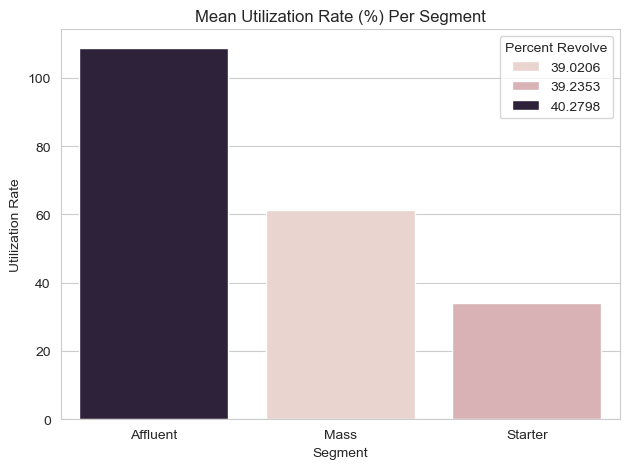

In [14]:
sns.barplot(data=df_cs_segmentation_mean, x='segment', y='utilization_rate', hue='pct_revolve')
plt.legend(title='Percent Revolve')
plt.title('Mean Utilization Rate (%) Per Segment')
plt.xlabel('Segment')
plt.ylabel('Utilization Rate')
plt.tight_layout()
plt.show()

#Affluent segment is the riskiest due to its high utilization rate among all segments, followed by Mass segment.
#High utilization indeed implies higher potential income, but also riskier.
#Also, Affluent segment has the highest percent revolve, which implies higher interest income
#It is pretty rare for utilization rate of affluent users to be >1, much more for the overall average.
#indicate citation for this claim.
#This indicates that there is abnormality affecting utilization rate.
#Next question: What are the factors affecting this?

In [15]:
df_affluent = df.query('segment == "Affluent"').copy()
df_affluent

,customer_id,age,segment,region,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
1,100002,49,Affluent,West,87,50000,19737.0,21,0,1,61360.0,1.23,0.39,23930.0,0
2,100003,35,Affluent,South,128,120000,7782.0,24,30,1,52927.0,0.44,0.27,14290.0,1
4,100005,28,Affluent,East,4,120000,20698.0,29,0,0,28070.0,0.23,0.35,9824.0,0
6,100007,59,Affluent,East,47,80000,17206.0,17,0,1,29890.0,0.37,0.28,8369.0,0
9,100010,31,Affluent,South,21,20000,20734.0,19,0,0,31783.0,1.59,0.40,12713.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,100963,65,Affluent,East,103,50000,13600.0,20,0,0,36298.0,0.73,0.34,12341.0,0
971,100972,60,Affluent,North,82,80000,15792.0,21,0,0,87966.0,1.10,0.03,2639.0,0
983,100984,57,Affluent,East,41,20000,12144.0,22,30,0,10555.0,0.53,0.84,8866.0,1
985,100986,42,Affluent,West,133,120000,24510.0,27,0,0,53227.0,0.44,0.32,17033.0,0


In [16]:
df_affluent.query('utilization_rate > 1.5')
#It is extremely rare to have utilization rate greater than 1.5,
#Given the percentage of customers with utilization rate > 1.5 (39/193 ~= 20.21%)
#put a citation regarding this claim na rare ang such instances
#insights insights insights

,customer_id,age,segment,region,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
9,100010,31,Affluent,South,21,20000,20734.0,19,0,0,31783.0,1.59,0.40,12713.0,0
15,100016,23,Affluent,West,39,20000,32471.0,22,0,0,34818.0,1.74,0.25,8704.0,0
55,100056,28,Affluent,North,124,20000,15593.0,15,0,0,46788.0,2.34,0.38,17779.0,0
109,100110,53,Affluent,East,45,20000,3109.0,17,90,0,74112.0,3.71,0.50,37056.0,1
150,100151,59,Affluent,West,61,20000,11432.0,24,0,0,99207.0,4.96,0.50,49604.0,0
171,100172,26,Affluent,East,136,50000,28622.0,27,0,0,91353.0,1.83,0.57,52071.0,0
197,100198,44,Affluent,North,39,50000,26994.0,19,0,0,97137.0,1.94,0.40,38855.0,0
219,100220,52,Affluent,South,153,20000,29521.0,25,0,0,33894.0,1.69,0.09,3050.0,0
226,100227,52,Affluent,North,175,20000,1000.0,21,0,0,48103.0,2.41,0.26,12507.0,0
259,100260,59,Affluent,East,155,20000,21540.0,19,0,0,74304.0,3.72,0.36,26749.0,0


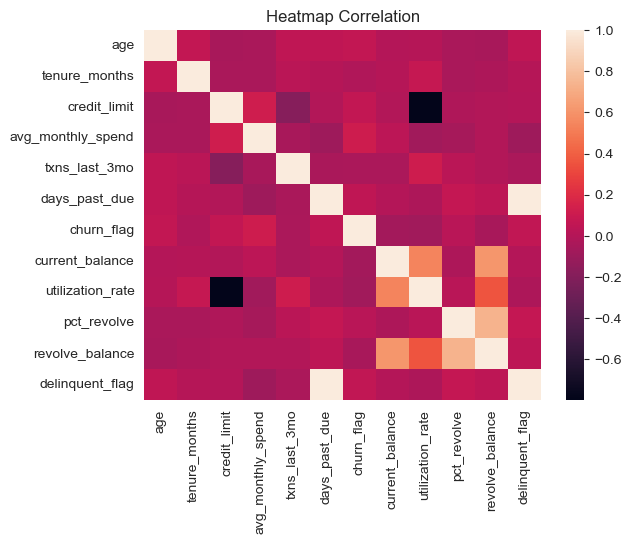

In [ ]:
df_affluent_corr = df_affluent.drop(['customer_id','segment', 'region'], axis=1)
sns.heatmap(data=df_affluent_corr.corr(numeric_only=True, method='spearman'))
plt.title('Heatmap Correlation')
plt.show()

#credit_limit & utilization_rate are highly inverse correlated
#utilization_rate and current_balance are moderately correlated #this is already given since utilization_rate = current_balance / credit_limit. Naturally, as current_balance increases, utilization_rate also increases. 
#revolve_balance and utilization_rate are also moderately correlated #this is given due to the fact that revolve_balance = current_balance * pct_revolve, and current_balance = utilization_rate * credit_limit.
#Therefore, as utilization_rate increases, current_balance also increases resulting to increase in revolve_balance.

#why does this company allow affluent with lower credit limits to go beyond the credit limit?
#we'll focus primarily on these correlations as they are significant.

## **Take note:**
#### The upper triangle of this matrix (including diagonal matrix are the p-values of the Spearman Rank Correlation). The lower triangle is the spearman correlation coefficient(rho)'

In [ ]:
#Check the for the assumptions of the correlation analysis to ensure validity
#Spearman correlation assumptions:
#Variables must be atleast ordinal level (all variables are at least ordinal level, except for delinquent_flag and churn_flag
#this is still valid since these can act as rank, and therefore ordinal level)
#Paired observations (all observations are per customerID)

cols = df_affluent_corr.columns
n = len(cols)

#Initialize matrices
corr_matrix = np.zeros((n, n))
pval_matrix = np.zeros((n, n))

#Compute Spearman correlation and p-values
for i in range(n):
    for j in range(n):
        rho, pval = stats.spearmanr(df[cols[i]], df[cols[j]])
        corr_matrix[i, j] = rho
        pval_matrix[i, j] = pval

#Build final matrix: lower triangle = correlation, upper triangle + diagonal = p-value
final_matrix = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        if i > j:
            final_matrix[i, j] = round(corr_matrix[i, j], 4)  # correlation
        else:
            final_matrix[i, j] = round(pval_matrix[i, j], 4)  # p-value

#Convert to DataFrame for readability
result = pd.DataFrame(final_matrix, index=cols, columns=cols)
result

Take note: The upper triangle of this matrix (including diagonal matrix are the p-values of the Spearman Rank Correlation). 
       The lower triangle is the spearman correlation coefficient(rho)


,age,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
age,0.0,0.7275,0.7298,0.0346,0.5302,0.9816,0.6224,0.0698,0.0614,0.7281,0.0625,0.9508
tenure_months,-0.011,0.0,0.7484,0.8659,0.7343,0.649,0.3511,0.6183,0.7338,0.04,0.2421,0.6257
credit_limit,-0.0109,0.0102,0.0,0.3076,0.0542,0.3166,0.7897,0.0305,0.0,0.3699,0.0779,0.2779
avg_monthly_spend,-0.0668,-0.0053,0.0323,0.0,0.0802,0.5179,0.0775,0.8987,0.5142,0.3475,0.9215,0.5116
txns_last_3mo,-0.0199,0.0107,-0.0609,-0.0553,0.0,0.0686,0.8027,0.8232,0.4478,0.0953,0.5439,0.0668
days_past_due,-0.0007,0.0144,0.0317,-0.0205,0.0576,0.0,0.556,0.2607,0.2421,0.2187,0.8473,0.0
churn_flag,0.0156,-0.0295,0.0084,0.0558,-0.0079,-0.0186,0.0,0.2495,0.2374,0.9492,0.5212,0.5474
current_balance,-0.0574,-0.0158,0.0684,0.004,-0.0071,-0.0356,-0.0364,0.0,0.0,0.4677,0.0,0.2615
utilization_rate,-0.0592,-0.0108,-0.6133,-0.0207,0.024,-0.037,-0.0374,0.6876,0.0,0.7473,0.0,0.2251
pct_revolve,-0.011,-0.0649,0.0284,-0.0297,0.0528,0.0389,0.002,0.023,0.0102,0.0,0.0,0.2293


In [ ]:
#In the case that rows with utilization_rate >=1.5 were erroneously encoded:
df_revised = df.query('utilization_rate < 1.5').copy()


,customer_id,age,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
customer_id,1.000000,-0.004604,-0.021805,-0.026274,-0.029503,-0.015556,0.024681,0.002121,-0.027777,0.030239,0.031550,-0.017699,0.012194
age,-0.004604,1.000000,-0.020424,-0.018197,-0.054094,-0.011554,-0.032297,0.017917,-0.058417,-0.058368,-0.007178,-0.043702,-0.004563
tenure_months,-0.021805,-0.020424,1.000000,0.036766,0.004485,0.010740,0.024851,-0.029354,-0.024538,-0.028599,-0.044292,-0.053127,0.028663
credit_limit,-0.026274,-0.018197,0.036766,1.000000,0.027097,-0.070691,-0.008139,-0.017508,0.189565,-0.509215,0.040580,0.158431,0.011183
avg_monthly_spend,-0.029503,-0.054094,0.004485,0.027097,1.000000,-0.079836,-0.020343,0.047610,0.036265,-0.006659,-0.026579,0.024726,-0.023282
txns_last_3mo,-0.015556,-0.011554,0.010740,-0.070691,-0.079836,1.000000,0.051562,0.001781,-0.015309,0.015861,0.049064,0.025700,0.057419
days_past_due,0.024681,-0.032297,0.024851,-0.008139,-0.020343,0.051562,1.000000,-0.016146,-0.023043,-0.011220,0.040362,-0.000121,0.907726
churn_flag,0.002121,0.017917,-0.029354,-0.017508,0.047610,0.001781,-0.016146,1.000000,-0.014230,-0.009940,-0.004278,-0.018521,-0.022156
current_balance,-0.027777,-0.058417,-0.024538,0.189565,0.036265,-0.015309,-0.023043,-0.014230,1.000000,0.548179,0.013314,0.727764,-0.012305
utilization_rate,0.030239,-0.058368,-0.028599,-0.509215,-0.006659,0.015861,-0.011220,-0.009940,0.548179,1.000000,0.005464,0.395406,-0.012102


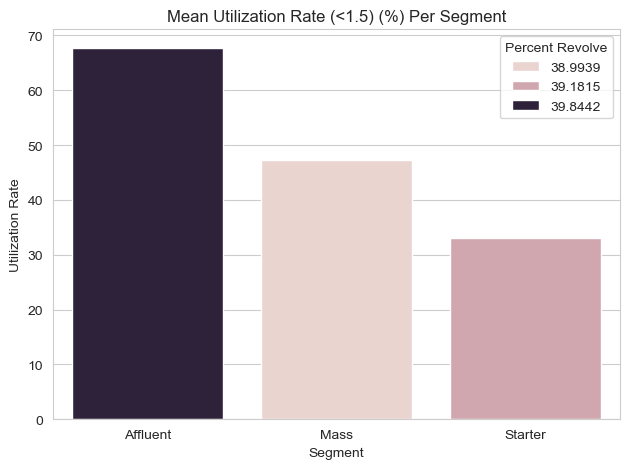

In [23]:
df_revised_mean = df_revised.groupby('segment')[['avg_monthly_spend', 'current_balance',
                                       'utilization_rate', 'pct_revolve', 'revolve_balance']].mean()
df_revised_mean['pct_revolve'] = df_revised_mean['pct_revolve'].round(6)
df_revised_mean['pct_revolve'] = df_revised_mean['pct_revolve']*100

df_revised_mean['utilization_rate'] = df_revised_mean['utilization_rate'].round(6)
df_revised_mean['utilization_rate'] = df_revised_mean['utilization_rate']*100

sns.barplot(data=df_revised_mean, x='segment', y='utilization_rate', hue='pct_revolve')
plt.legend(title='Percent Revolve')
plt.title('Mean Utilization Rate (<1.5) (%) Per Segment')
plt.xlabel('Segment')
plt.ylabel('Utilization Rate')
plt.tight_layout()
plt.show()

In [27]:
df_above1_5 = df.query('utilization_rate >= 1.5').copy()
df_above1_5

,customer_id,age,segment,region,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
9,100010,31,Affluent,South,21,20000,20734.0,19,0,0,31783.0,1.59,0.40,12713.0,0
11,100012,44,Mass,South,117,20000,18156.0,17,0,0,43722.0,2.19,0.20,8744.0,0
15,100016,23,Affluent,West,39,20000,32471.0,22,0,0,34818.0,1.74,0.25,8704.0,0
16,100017,42,Mass,South,137,20000,19720.0,20,0,0,66790.0,3.34,0.47,31391.0,0
26,100027,42,Mass,North,38,20000,1280.0,19,0,0,31281.0,1.56,0.56,17517.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
860,100861,33,Affluent,South,86,20000,17257.0,16,0,0,58307.0,2.92,0.36,20991.0,0
877,100878,52,Mass,North,70,20000,24467.0,18,0,0,31884.0,1.59,0.39,12435.0,0
892,100893,25,Affluent,East,102,20000,15620.0,22,0,0,89287.0,4.46,0.55,49108.0,0
926,100927,44,Mass,East,74,20000,44792.0,19,0,0,42689.0,2.13,0.45,19210.0,0


In [28]:
df_above1_5.describe()

,customer_id,age,tenure_months,credit_limit,avg_monthly_spend,txns_last_3mo,days_past_due,churn_flag,current_balance,utilization_rate,pct_revolve,revolve_balance,delinquent_flag
count,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000
mean,100458.272727,44.977273,96.329545,21363.636364,17030.806818,22.295455,2.045455,0.068182,49467.318182,2.352273,0.406591,20299.136364,0.022727
std,277.278014,13.410390,50.870745,6284.777848,8915.703026,4.611727,13.489808,0.253502,17796.560930,0.785025,0.183070,12291.868885,0.149887
min,100010.000000,21.000000,6.000000,20000.000000,1000.000000,12.000000,0.000000,0.000000,30206.000000,1.510000,0.070000,2688.000000,0.000000
25%,100231.500000,34.000000,53.500000,20000.000000,11277.750000,19.000000,0.000000,0.000000,35181.000000,1.747500,0.297500,11814.250000,0.000000
50%,100436.000000,46.000000,98.500000,20000.000000,16853.000000,22.000000,0.000000,0.000000,43978.000000,2.130000,0.390000,17238.500000,0.000000
75%,100712.000000,55.000000,138.250000,20000.000000,21799.000000,25.000000,0.000000,0.000000,57257.750000,2.735000,0.525000,27668.500000,0.000000
max,100931.000000,69.000000,175.000000,50000.000000,44792.000000,34.000000,90.000000,1.000000,99207.000000,4.960000,0.890000,52071.000000,1.000000
